### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import metrics

In [4]:
from feature_engine.selection import SmartCorrelatedSelection

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier

### Step 2: Load Data

In [6]:
df = pd.read_csv('./data/spaceship_titanic.csv')

In [7]:
df.shape

(8693, 14)

In [8]:
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


### Step 3: Exploaring Data

#### Basic Info

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,8514.0,28.827930,14.489021,0.0,19.0,27.0,38.0,79.0
RoomService,8512.0,224.687617,666.717663,0.0,0.0,0.0,47.0,14327.0
FoodCourt,8510.0,458.077203,1611.489240,0.0,0.0,0.0,76.0,29813.0
ShoppingMall,8485.0,173.729169,604.696458,0.0,0.0,0.0,27.0,23492.0
Spa,8510.0,311.138778,1136.705535,0.0,0.0,0.0,59.0,22408.0
VRDeck,8505.0,304.854791,1145.717189,0.0,0.0,0.0,46.0,24133.0


In [10]:
feature_info = pd.DataFrame(
    {
        'null': df.isnull().sum(),
        'null(%)': round(100 * df.isnull().sum() / len(df), 3),
        'unique': df.nunique(),
        'type': df.dtypes
    }
)
feature_info

,null,null(%),unique,type
PassengerId,0,0.000,8693,object
HomePlanet,201,2.312,3,object
CryoSleep,217,2.496,2,object
Cabin,199,2.289,6560,object
Destination,182,2.094,3,object
Age,179,2.059,80,float64
VIP,203,2.335,2,object
RoomService,181,2.082,1273,float64
FoodCourt,183,2.105,1507,float64
ShoppingMall,208,2.393,1115,float64


#### Target Distribution

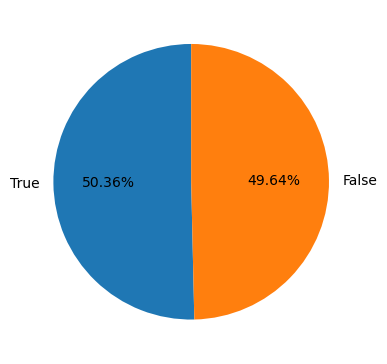

In [11]:
temp = df['Transported'].value_counts()
plt.figure(figsize=(4, 4))
plt.pie(
    temp,
    autopct='%.2f%%',
    labels=temp.index,
    startangle=90
)
plt.tight_layout()

#### Float Distribution

In [12]:
float_cols = df.select_dtypes(np.float_).columns.to_list()

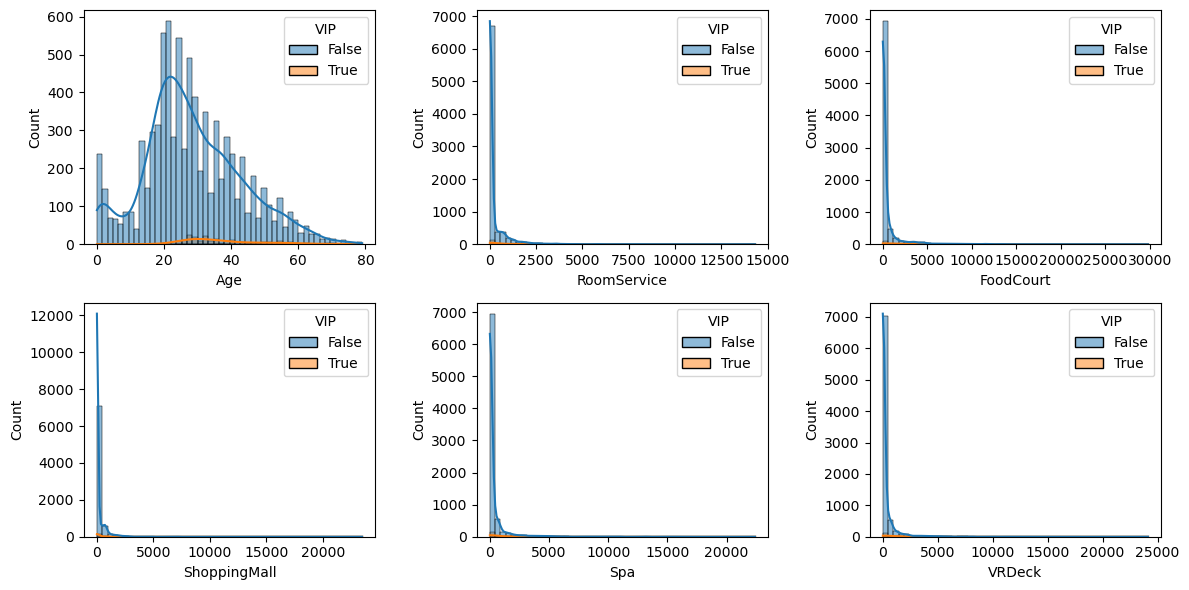

In [13]:
plt.figure(figsize=(12, 6))
for i, col in enumerate(float_cols):
    plt.subplot(2, 3, i+1)
    sns.histplot(x=col, hue='VIP', data=df, bins=50, kde=True)
plt.tight_layout()

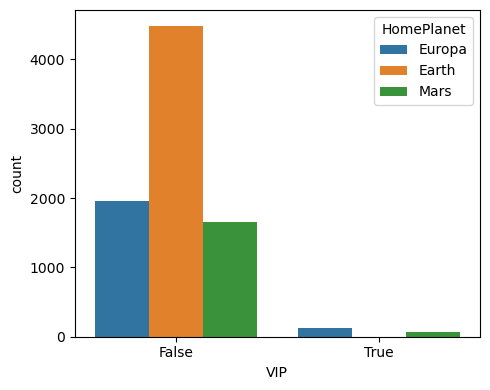

In [19]:
plt.figure(figsize=(5, 4))
sns.countplot(x='VIP', hue='HomePlanet', data=df)
plt.tight_layout()

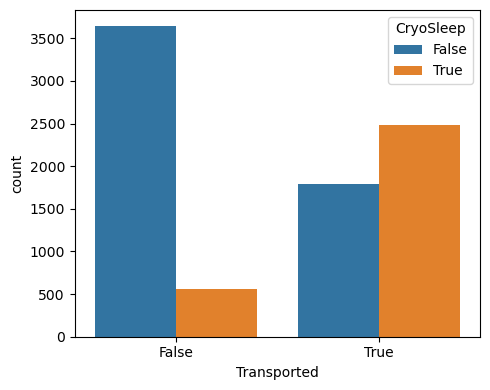

In [33]:
plt.figure(figsize=(5, 4))
sns.countplot(x='Transported', hue='CryoSleep', data=df)
plt.tight_layout()

### Step 4: Feature Engineering

#### Handling Missing Value

In [14]:
for col in float_cols:
    if col == 'Age':
        continue
    temp = df['CryoSleep']==True
    df.loc[temp, col] = df.loc[temp, col].fillna(0.0)
    
    temp = df['VIP'] == True
    df.loc[temp, col] = df.loc[temp, col].fillna(df.loc[temp, col].mean())

    temp = df['VIP'] == False
    df.loc[temp, col] = df.loc[temp, col].fillna(df.loc[temp, col].mean())

In [39]:
temp = df['VIP'] == False
df.loc[temp, 'HomePlanet'] = df.loc[temp, 'HomePlanet'].fillna(df.loc[temp, 'HomePlanet'].mode()[0])

temp = df['VIP'] == True
df.loc[temp, 'HomePlanet'] = df.loc[temp, 'HomePlanet'].fillna(df.loc[temp, 'HomePlanet'].mode()[0])

In [31]:
df['Age'] = df['Age'].fillna(df[df['Age'] < 61]['Age'].mean())

In [52]:
for col in df.columns:
    if df[col].isnull().sum() == 0:
        continue

    if df[col].dtype == object or df[col].dtype == bool:
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].mean())

#### Create Feature

In [82]:
temp = df["PassengerId"].str.split("_", n=1, expand=True).astype(int)

In [83]:
df['PassengerNo'] = temp[0].map(temp[0].value_counts())

In [88]:
df.drop('PassengerId', axis=1, inplace=True)

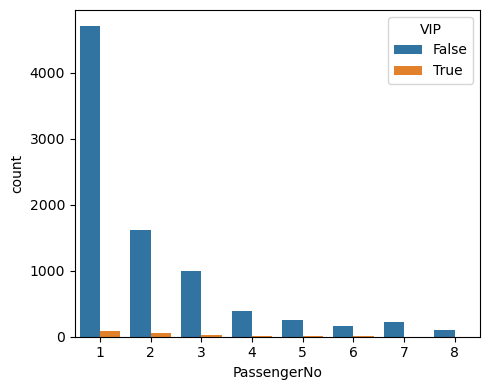

In [90]:
plt.figure(figsize=(5, 4))
sns.countplot(x='PassengerNo', hue='VIP', data=df)
plt.tight_layout()

In [91]:
df[['F1', 'F2', 'F3']] = df['Cabin'].str.split('/', expand=True)

In [92]:
df['F2'] = df['F2'].astype(int)

In [93]:
df.drop('Cabin', axis=1, inplace=True)

In [94]:
df['LeasureBill'] = df['RoomService'] + df['FoodCourt'] + df['ShoppingMall'] + df['Spa'] + df['VRDeck']

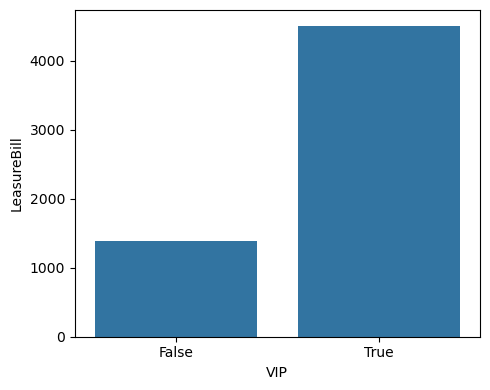

In [100]:
plt.figure(figsize=(5, 4))
sns.barplot(x='VIP', y='LeasureBill', data=df, errorbar=None)
plt.tight_layout()

#### Label Encode

In [104]:
obj_cols = df.select_dtypes(np.object_).columns

In [106]:
df[obj_cols] = df[obj_cols].apply(LabelEncoder().fit_transform)

In [107]:
bool_cols = df.select_dtypes(np.bool_).columns

In [108]:
df[bool_cols] = df[bool_cols].astype(int)

#### Heat Map

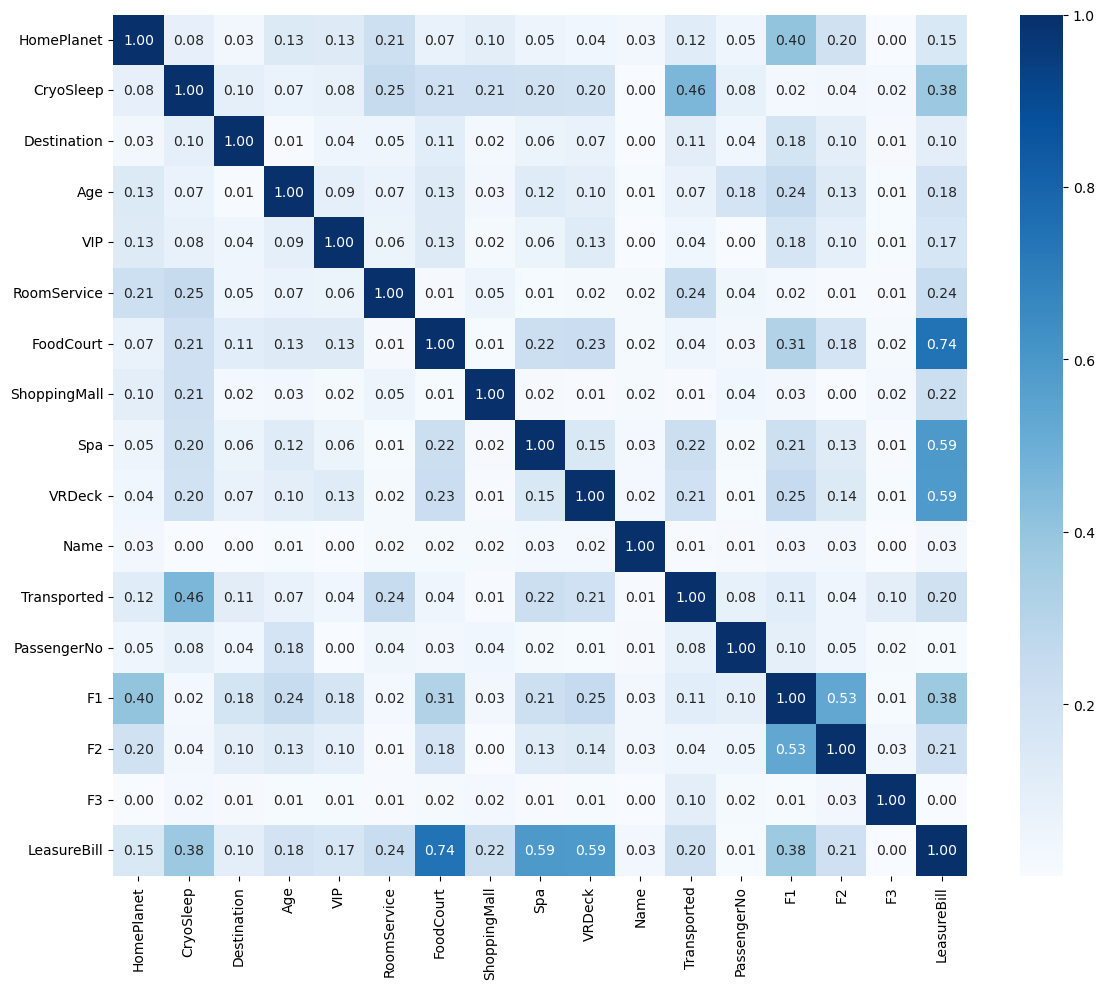

In [109]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    df.corr().abs(),
    fmt='.2f',
    annot=True,
    cmap=plt.cm.Blues
)
plt.tight_layout()

### Step 5: Preparing Data

#### Select Features

In [135]:
features = df.drop(['Name', 'Transported'], axis=1)
target = df['Transported']

In [136]:
raw_features = features.columns.to_list()

In [137]:
selector = SmartCorrelatedSelection(threshold=0.8, selection_method='corr_with_target')

In [138]:
features = selector.fit_transform(features, target)

In [139]:
deal_features = features.columns.to_list()

In [140]:
delete_features = list(set(raw_features) - set(deal_features))

In [141]:
print('raw featuers:', raw_features)
print('deal featuers:', deal_features)
print('delete featuers:', delete_features)

raw featuers: ['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'PassengerNo', 'F1', 'F2', 'F3', 'LeasureBill']
deal featuers: ['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'PassengerNo', 'F1', 'F2', 'F3', 'LeasureBill']
delete featuers: []


#### Split Data

In [147]:
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

#### Normalization

In [148]:
scaler = StandardScaler()

In [149]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Step 6: Model Development

In [150]:
models = [
    LogisticRegression(),
    XGBClassifier(),
    SVC(probability=True)
]

In [151]:
for model in models:
    print(f'model: {model.__class__.__name__}')
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1,
        error_score='raise'
    )
    print('training accurary scores:', [round(score, 3) for score in scores])
    print('training accurary score:', round(scores.mean(), 3))

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print('testing accuracy score:', round(metrics.roc_auc_score(y_test, y_pred), 3))
    print('-' * 20)

model: LogisticRegression
training accurary scores: [0.869, 0.88, 0.87, 0.869, 0.888]
training accurary score: 0.875
testing accuracy score: 0.768
--------------------
model: XGBClassifier
training accurary scores: [0.892, 0.903, 0.888, 0.897, 0.904]
training accurary score: 0.897
testing accuracy score: 0.806
--------------------
model: SVC
training accurary scores: [0.871, 0.878, 0.872, 0.872, 0.887]
training accurary score: 0.876
testing accuracy score: 0.791
--------------------


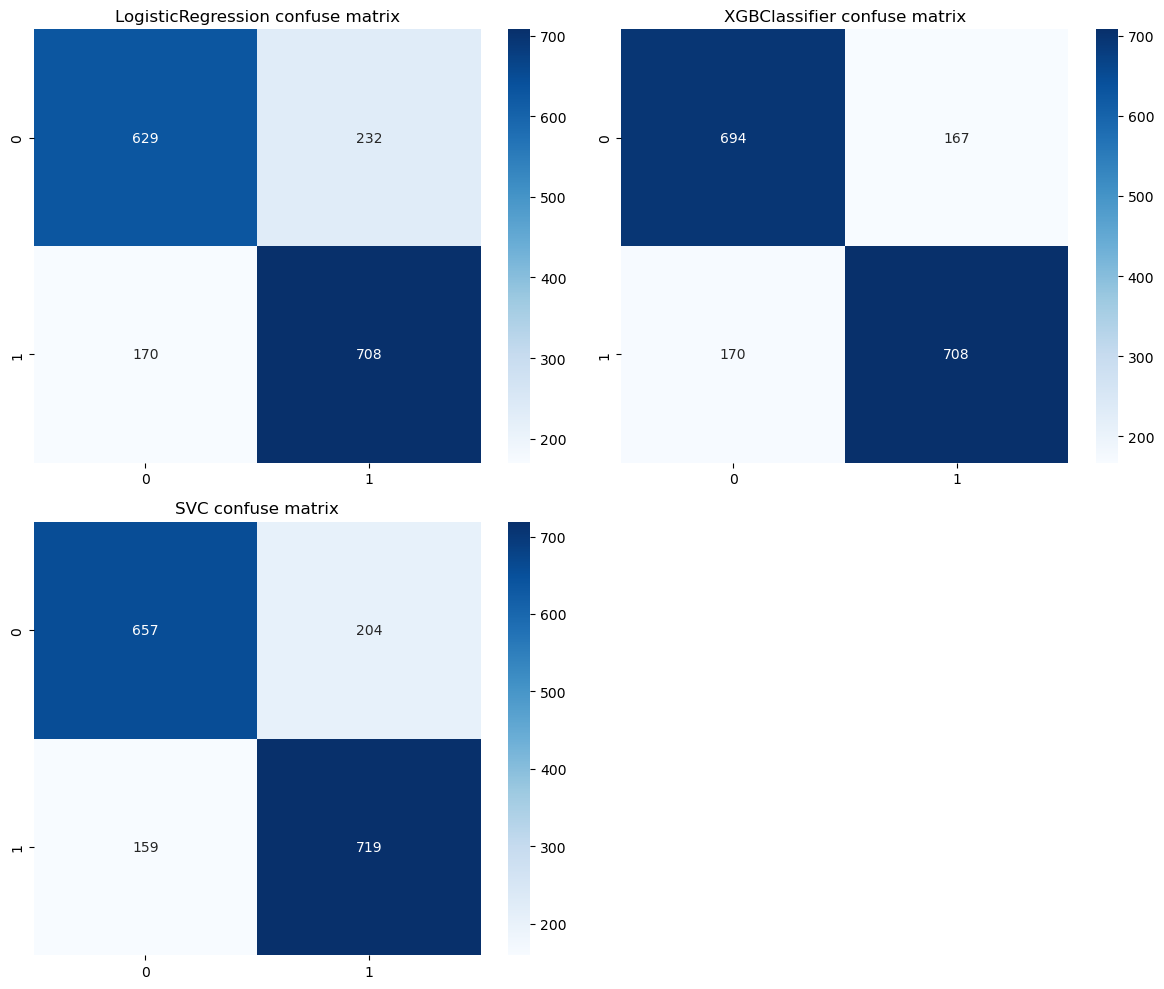

In [152]:
plt.figure(figsize=(12, 10))
for i, model in enumerate(models):
    plt.subplot(2, 2, i+1)
    cm = metrics.confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(
        cm,
        fmt='d',
        annot=True,
        cmap=plt.cm.Blues
    )
    plt.title(f'{model.__class__.__name__} confuse matrix')
plt.tight_layout()

In [155]:
for model in models:
    print('-'*20, model.__class__.__name__, '-'*20)
    print(metrics.classification_report(y_test, model.predict(X_test)))

-------------------- LogisticRegression --------------------
              precision    recall  f1-score   support

           0       0.79      0.73      0.76       861
           1       0.75      0.81      0.78       878

    accuracy                           0.77      1739
   macro avg       0.77      0.77      0.77      1739
weighted avg       0.77      0.77      0.77      1739

-------------------- XGBClassifier --------------------
              precision    recall  f1-score   support

           0       0.80      0.81      0.80       861
           1       0.81      0.81      0.81       878

    accuracy                           0.81      1739
   macro avg       0.81      0.81      0.81      1739
weighted avg       0.81      0.81      0.81      1739

-------------------- SVC --------------------
              precision    recall  f1-score   support

           0       0.81      0.76      0.78       861
           1       0.78      0.82      0.80       878

    accuracy       